In [13]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

%matplotlib inline

import pandas as pd
import numpy as np
import vectorbt as vbt
from typing import Tuple, Dict, List

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Bundle shape: (37946, 171)
Bundle columns: ['QQQ_S_open_f32', 'QQQ_S_high_f32', 'QQQ_S_low_f32', 'QQQ_S_close_f32', 'QQQ_S_volume_f64', 'QQQ_S_open_time_i', 'QQQ_S_close_time_i', 'QQQ_minute_diff', 'QQQ_gap_flag', 'QQQ_valid_row']...
ETFs found: ['GDX', 'GLD', 'QQQ', 'SHV', 'SPY', 'TLT', 'VWO', 'XLB', 'XLE', 'XME']


<Axes: >

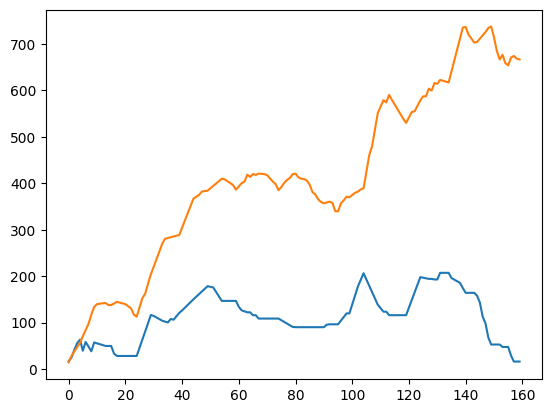

In [14]:
BUNDLE_PATH = '/data/bundle/etf_x_list_features_bundle.parquet'

df_bundle = pd.read_parquet(BUNDLE_PATH)
print(f"Bundle shape: {df_bundle.shape}")
print(f"Bundle columns: {df_bundle.columns.tolist()[:10]}...")

def get_etf_symbols(df: pd.DataFrame) -> List[str]:
    symbols = set()
    for col in df.columns:
        if '_S_close_f32' in col:
            symbols.add(col.split('_')[0])
    return sorted(symbols)

etf_symbols = get_etf_symbols(df_bundle)
print(f"ETFs found: {etf_symbols}")

# =========================
# Flexible column mapping
# =========================

def prepare_data(df, openname, highname, lowname, closename, volname):
    data = pd.DataFrame()
    data['open'] = df[openname]
    data['high'] = df[highname]
    data['low'] = df[lowname]
    data['close'] = df[closename]
    data['volume'] = df[volname]
    return data

# =========================
# Indicators
# =========================

def compute_atr(high, low, close, window):
    high_low = high - low
    high_close = (high - close.shift()).abs()
    low_close = (low - close.shift()).abs()
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    return tr.rolling(window).mean()

# =========================
# Strategy logic
# =========================

def build_signals(data, atr_window=14, lookback=30, atr_mult=1.0):
    atr = compute_atr(data['high'], data['low'], data['close'], atr_window)

    range_high = data['high'].rolling(lookback).max()
    range_low = data['low'].rolling(lookback).min()

    long_entries = (
        (data['close'] > range_high.shift(1)) &
        (data['close'] > range_high.shift(1) + atr_mult * atr)
    )

    short_entries = (
        (data['close'] < range_low.shift(1)) &
        (data['close'] < range_low.shift(1) - atr_mult * atr)
    )

    return long_entries, short_entries, atr

# =========================
# Backtest function
# =========================

def run_backtest(df,
                 openname='open',
                 highname='high',
                 lowname='low',
                 closename='close',
                 volname='volume',
                 atr_window=14,
                 lookback=30,
                 atr_mult=1.0,
                 fees=0.0005,
                 slippage=0.0005):

    data = prepare_data(df, openname, highname, lowname, closename, volname)

    long_entries, short_entries, atr = build_signals(
        data,
        atr_window=atr_window,
        lookback=lookback,
        atr_mult=atr_mult
    )

    # exits (reverse signals)
    long_exits = short_entries
    short_exits = long_entries

    pf = vbt.Portfolio.from_signals(
        close=data['close'],
        entries=long_entries,
        exits=long_exits,
        short_entries=short_entries,
        short_exits=short_exits,
        fees=fees,
        slippage=slippage,
        freq='1min'
    )

    return pf

# =========================
# Parameter Optimization
# =========================

def optimize_strategy(df,
                      openname='open',
                      highname='high',
                      lowname='low',
                      closename='close',
                      volname='volume'):

    data = prepare_data(df, openname, highname, lowname, closename, volname)

    atr_windows = [10, 14, 20]
    lookbacks = [15, 30, 60]
    atr_mults = [0.8, 1.0, 1.2]

    results = []

    for aw in atr_windows:
        for lb in lookbacks:
            for am in atr_mults:
                long_entries, short_entries, _ = build_signals(
                    data,
                    atr_window=aw,
                    lookback=lb,
                    atr_mult=am
                )

                pf = vbt.Portfolio.from_signals(
                    close=data['close'],
                    entries=long_entries,
                    exits=short_entries,
                    short_entries=short_entries,
                    short_exits=long_entries,
                    fees=0.0005,
                    slippage=0.0005,
                    freq='1min'
                )

                results.append({
                    'atr_window': aw,
                    'lookback': lb,
                    'atr_mult': am,
                    'return': pf.total_return(),
                    'sharpe': pf.sharpe_ratio()
                })

    results_df = pd.DataFrame(results)
    return results_df.sort_values('sharpe', ascending=False)


# =========================
# Example usage
# =========================

trained_portfolios = []
realised_portfolios = []
portfolio_train_pnl = []

sum_returns_test = 0
sum_returns_train = 0

portfolio_pnl = []
atr = []
lookbacks = []
atr_mults =[]

for i in range(32):

    start_i = i * 1000
    end_i = (i+5) * 1000
    end_test_i = (i+6) * 1000
    opt = optimize_strategy(df_bundle[start_i:end_i],openname='QQQ_S_open_f32',
                  highname='QQQ_S_high_f32',
                  lowname='QQQ_S_low_f32',
                  closename='QQQ_S_close_f32',
                  volname='QQQ_S_volume_f64')
    
    top5 = opt.head()
    train_5 = []
    count_top = 0
    for j, row in top5.iterrows():
        pf = run_backtest(
            df_bundle[end_i-1000:end_i],
            openname='QQQ_S_open_f32',
            highname='QQQ_S_high_f32',
            lowname='QQQ_S_low_f32',
            closename='QQQ_S_close_f32',
            volname='QQQ_S_volume_f64',
            atr_window=int(row['atr_window']),
            lookback=int(row['lookback']),
            atr_mult=float(row['atr_mult'])
        )
        atr.append(int(row['atr_window']))
        lookbacks.append(int(row['lookback']))
        atr_mults.append(float(row['atr_mult']))
        
        #print(pf.stats())
        train_5.append(pf.stats()['Total Return [%]'])
        
        pnl_period = 0
        pnl_period +=pf.stats()['Total Return [%]']
        
        #print('train :' + str(int(pf.stats()['Total Return [%]']*100)))
        trained_portfolios.append(pf)    
        sum_returns_train +=pf.stats()['Total Return [%]']

        portfolio_train_pnl.append(pnl_period)

    for j, row in top5.iterrows():
        pf = run_backtest(
            df_bundle[end_i+1:end_test_i],
            openname='QQQ_S_open_f32',
            highname='QQQ_S_high_f32',
            lowname='QQQ_S_low_f32',
            closename='QQQ_S_close_f32',
            volname='QQQ_S_volume_f64',
            atr_window=int(row['atr_window']),
#            lookback=int(row['lookback']),
            lookback=int(45),
#            atr_mult=float(row['atr_mult'])
             atr_mult=float(1)
 
        )

        pnl_period = 0
        if train_5[count_top] >= 0:
            sum_returns_test +=pf.stats()['Total Return [%]']
            pnl_period +=pf.stats()['Total Return [%]']
            #print('test :' + str(int(pf.stats()['Total Return [%]']*100)))
            
        portfolio_pnl.append(pnl_period)
        
        count_top +=1
        
        realised_portfolios.append(pf)

pd.Series(portfolio_pnl).cumsum().plot()
pd.Series(portfolio_train_pnl).cumsum().plot()

In [15]:
#portfolio_pnl.cumsum.plot()



<Axes: >

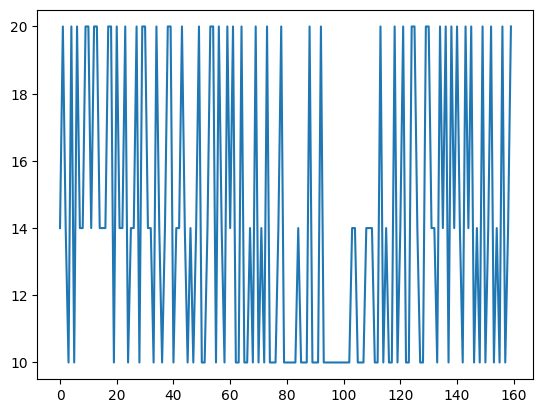

In [16]:
pd.Series(atr).plot()

<Axes: >

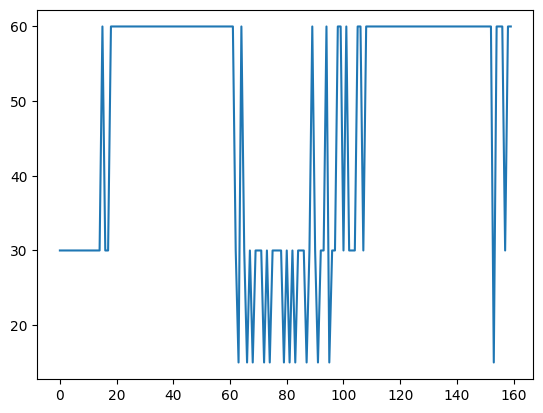

In [17]:
pd.Series(lookbacks).plot()

,atr_window,lookback,atr_mult,return,sharpe
8,10,60,1.2,0.284933,10.022223
26,20,60,1.2,0.215601,8.387163
5,10,30,1.2,0.154076,6.336263
17,14,60,1.2,0.117671,5.336292
25,20,60,1.0,0.036408,2.760432


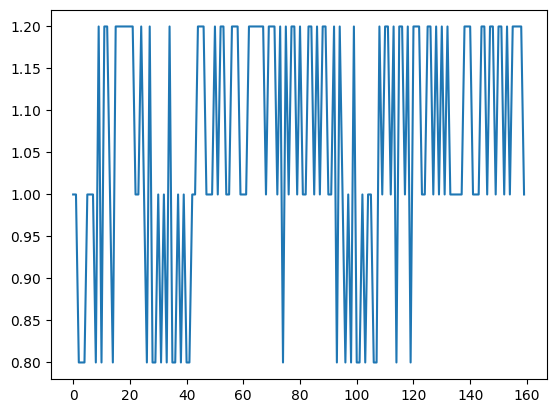

In [18]:
pd.Series(atr_mults).plot()
top5

In [19]:
pf = run_backtest(df_bundle,
                  openname='QQQ_S_open_f32',
                  highname='QQQ_S_high_f32',
                  lowname='QQQ_S_low_f32',
                  closename='QQQ_S_close_f32',
                  volname='QQQ_S_volume_f64')

print(pf.stats())

Start                                                 0
End                                               37945
Period                                 26 days 08:26:00
Start Value                                       100.0
End Value                                     96.582118
Total Return [%]                              -3.417882
Benchmark Return [%]                        1435.077763
Max Gross Exposure [%]                            100.0
Total Fees Paid                                31.07224
Max Drawdown [%]                               63.47947
Max Drawdown Duration                  22 days 04:33:00
Total Trades                                        211
Total Closed Trades                                 210
Total Open Trades                                     1
Open Trade PnL                                -1.468234
Win Rate [%]                                  39.047619
Best Trade [%]                                35.381854
Worst Trade [%]                              -10

In [20]:
opt = optimize_strategy(df_bundle[:5000],openname='QQQ_S_open_f32',
                  highname='QQQ_S_high_f32',
                  lowname='QQQ_S_low_f32',
                  closename='QQQ_S_close_f32',
                  volname='QQQ_S_volume_f64')
print(opt.head())

    atr_window  lookback  atr_mult    return     sharpe
13          14        30       1.0  1.307309  25.546681
22          20        30       1.0  1.307309  25.546681
12          14        30       0.8  1.253920  22.362309
3           10        30       0.8  1.210771  21.907598
21          20        30       0.8  1.187412  21.587581


In [21]:
pf = run_backtest(df_bundle[5000:6000],
                  openname='QQQ_S_open_f32',
                  highname='QQQ_S_high_f32',
                  lowname='QQQ_S_low_f32',
                  closename='QQQ_S_close_f32',
                  volname='QQQ_S_volume_f64',
                 atr_window=14,
                 lookback=30,
                 atr_mult=1.0,
                 fees=0.0005,
                 slippage=0.0005)
print(pf.stats())

Start                                                     5000
End                                                       5999
Period                                         0 days 16:40:00
Start Value                                              100.0
End Value                                           113.236955
Total Return [%]                                     13.236955
Benchmark Return [%]                                 17.182064
Max Gross Exposure [%]                                   100.0
Total Fees Paid                                       0.260928
Max Drawdown [%]                                      8.435187
Max Drawdown Duration                          0 days 06:50:00
Total Trades                                                 3
Total Closed Trades                                          2
Total Open Trades                                            1
Open Trade PnL                                        9.332374
Win Rate [%]                                           

In [22]:
trained_portfolios = []
realised_portfolios = []

sum_returns_test = 0
sum_returns_train = 0

portfolio_pnl = []

for i in range(20):

    start_i = i * 1000
    end_i = (i+5) * 1000
    end_test_i = (i+6) * 1000
    opt = optimize_strategy(df_bundle[start_i:end_i],openname='QQQ_S_open_f32',
                  highname='QQQ_S_high_f32',
                  lowname='QQQ_S_low_f32',
                  closename='QQQ_S_close_f32',
                  volname='QQQ_S_volume_f64')
    
    top5 = opt.head()
    train_5 = []
    count_top = 0
    for j, row in top5.iterrows():
        pf = run_backtest(
            df_bundle[end_i-1000:end_i],
            openname='QQQ_S_open_f32',
            highname='QQQ_S_high_f32',
            lowname='QQQ_S_low_f32',
            closename='QQQ_S_close_f32',
            volname='QQQ_S_volume_f64',
            atr_window=int(row['atr_window']),
            lookback=int(row['lookback']),
            atr_mult=float(row['atr_mult'])
        )
        
        #print(pf.stats())
        train_5.append(pf.stats()['Total Return [%]'])
        print('train :' + str(int(pf.stats()['Total Return [%]']*100)))
        trained_portfolios.append(pf)    
        sum_returns_train +=pf.stats()['Total Return [%]']
        

    for j, row in top5.iterrows():
        pf = run_backtest(
            df_bundle[end_i+1:end_test_i],
            openname='QQQ_S_open_f32',
            highname='QQQ_S_high_f32',
            lowname='QQQ_S_low_f32',
            closename='QQQ_S_close_f32',
            volname='QQQ_S_volume_f64',
            atr_window=int(row['atr_window']),
            lookback=int(row['lookback']),
            atr_mult=float(row['atr_mult'])
        )

        if train_5[count_top] >= 0:
            sum_returns_test +=pf.stats()['Total Return [%]']
            
        portfolio_pnl
        
        count_top +=1
        print('test :' + str(int(pf.stats()['Total Return [%]']*100)))
        
        realised_portfolios.append(pf)

train :1399
train :1399
train :948
train :948
train :948
test :1323
test :1323
test :1989
test :1989
test :1989
train :1418
train :1323
train :1323
train :1989
train :1677
test :-1959
test :88
test :-1344
test :-456
test :88
train :592
train :88
train :88
train :88
train :-456
test :-1227
test :342
test :342
test :153
test :-823
train :-17
train :342
train :342
train :-147
train :-155
test :-455
test :-2857
test :-2070
test :-171
test :-455
train :-171
train :-455
train :-455
train :-1337
train :-455
test :979
test :979
test :1994
test :1994
test :979
train :1994
train :1997
train :979
train :2162
train :1994
test :1644
test :1644
test :1086
test :1644
test :1644
train :1644
train :1644
train :1644
train :1644
train :1086
test :162
test :162
test :162
test :162
test :-31
train :162
train :162
train :162
train :162
train :162
test :1565
test :1565
test :1565
test :412
test :1565
train :1565
train :1565
train :1565
train :1565
train :1565
test :-828
test :89
test :89
test :89
test :407
t

In [23]:
sum_returns_train

np.float64(369.9931562000891)

In [12]:
sum_returns_test

np.float64(54.347566154035775)